Stappenplan:
- open cargo data 
- bereken vervolgens per MMSI gemiddelde snelheid van de boot (gebruik hier kolom SOG voor) 
- SOG is wel in knots dus dit moet je nog omrekenen naar km/u (1 knots = 1.852 kph)
- maak dan vervolgens een blokplot van de verdeling van snelheid per MMSI
- op basis hiervan kan je dan outliers verwijderen 
- en dus alleen routes toestaan die niet in deze outliers vallen 

In [ ]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [63]:
cargo_AIS_data = pd.read_parquet("../data/processed/cargo_vessels.parquet")
relevant_columns = ["MMSI", "IMO", "BaseDateTime", "LAT", "LON", "SOG", "Heading"]
cargo_AIS_data = cargo_AIS_data[relevant_columns]

cargo_AIS_data.head(5)

,MMSI,IMO,BaseDateTime,LAT,LON,SOG,Heading
49,367121040,IMO7634226,2024-01-01 00:00:03,41.54617,-82.72934,0.0,184.0
118,212719000,IMO9698238,2024-01-01 00:00:02,34.52975,-120.94588,10.4,322.0
121,367050160,IMO7514713,2024-01-01 00:00:03,46.75197,-92.13539,0.0,137.0
128,538007479,IMO9347542,2024-01-01 00:00:06,37.68875,-122.69553,6.0,7.0
133,477133500,IMO9638434,2024-01-01 00:00:02,38.07199,-124.04890,13.1,327.0


In [114]:
# counts
MMSI_counts = cargo_AIS_data["MMSI"].value_counts().reset_index()
MMSI_counts

,MMSI,count
0,368231430,39372
1,367585560,37301
2,367766220,37127
3,316023341,37017
4,368206160,37000
...,...,...
2395,374779000,1
2396,355528000,1
2397,538004890,1
2398,338815000,1


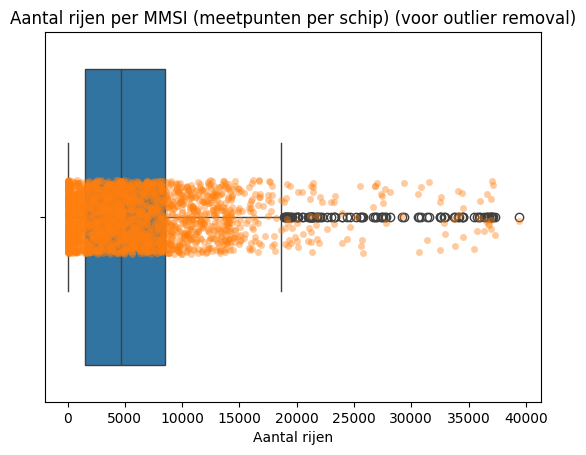

In [113]:
sns.boxplot(data = MMSI_counts, x = "count")
sns.stripplot(data = MMSI_counts, x = "count", alpha=0.4, jitter=True)
plt.title("Aantal rijen per MMSI (meetpunten per schip) (voor outlier removal)")
plt.xlabel("Aantal rijen")
plt.show()

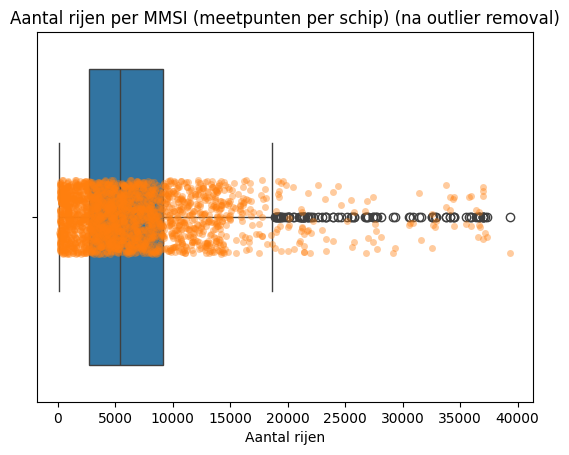

In [112]:
filtered_counts = MMSI_counts[MMSI_counts["count"] >= 150]

sns.boxplot(data = filtered_counts, x = "count")
sns.stripplot(data = filtered_counts, x = "count", alpha=0.4, jitter=True)
plt.title("Aantal rijen per MMSI (meetpunten per schip) (na outlier removal)")
plt.xlabel("Aantal rijen")
plt.show()

In [183]:
filtered_counts

,MMSI,count
0,368231430,39372
1,367585560,37301
2,367766220,37127
3,316023341,37017
4,368206160,37000
...,...,...
2128,416498000,160
2129,671051000,156
2130,563935000,155
2131,636022352,153


In [228]:
# speed
filtered_cargo_data = cargo_AIS_data[cargo_AIS_data["MMSI"].isin(filtered_counts["MMSI"].unique())].copy()
filtered_cargo_data["SOG_kph"] = filtered_cargo_data["SOG"] * 1.852
avg_speed_per_ship = filtered_cargo_data.groupby("MMSI")["SOG_kph"].mean().reset_index()
avg_speed_per_ship

,MMSI,SOG_kph
0,205717000,12.449517
1,209017000,21.403084
2,209087000,14.027724
3,209109000,3.810129
4,209112000,3.731009
...,...,...
2128,671969100,4.325266
2129,677059800,14.499794
2130,720202000,1.377849
2131,750000045,15.033980


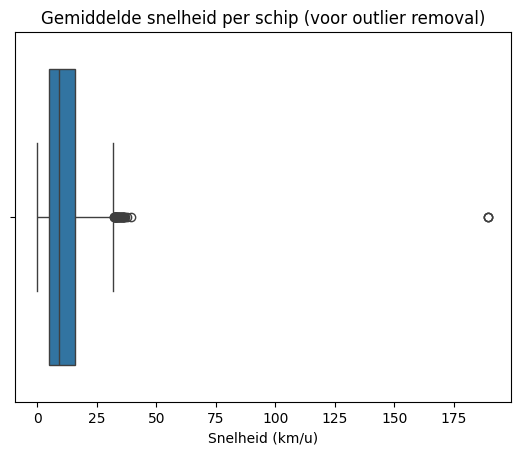

In [229]:
sns.boxplot(data = avg_speed_per_ship, x = "SOG_kph")
plt.title("Gemiddelde snelheid per schip (voor outlier removal)")
plt.xlabel("Snelheid (km/u)")
plt.show()

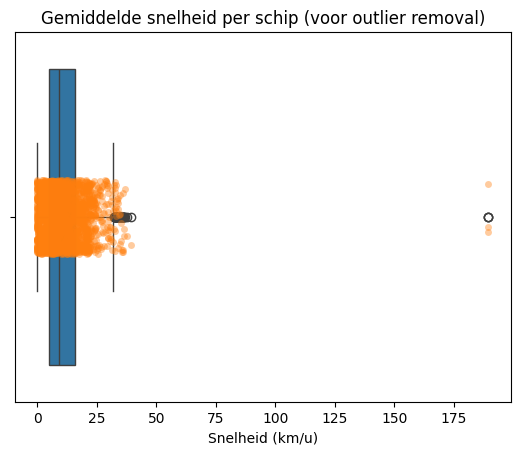

In [230]:
sns.boxplot(data = avg_speed_per_ship, x = "SOG_kph")
sns.stripplot(data = avg_speed_per_ship, x = "SOG_kph", alpha=0.4, jitter=True)
plt.title("Gemiddelde snelheid per schip (voor outlier removal)")
plt.xlabel("Snelheid (km/u)")
plt.show()

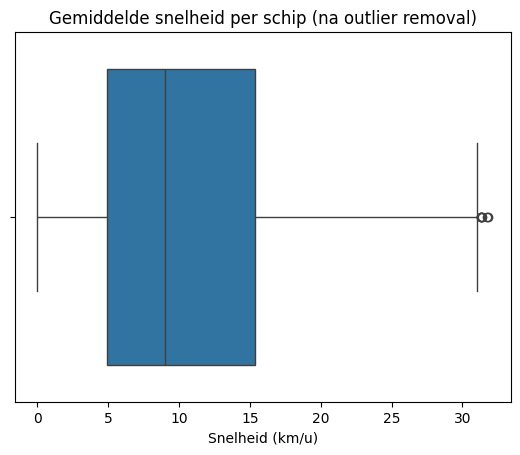

In [231]:
# gebaseerd op deze strategie:
# https://medium.com/@noorfatimaafzalbutt/outliers-detection-and-removal-using-iqr-method-e629aa8089a8 
Q1 = avg_speed_per_ship["SOG_kph"].quantile(0.25)
Q3 = avg_speed_per_ship["SOG_kph"].quantile(0.75)

IQR = Q3 - Q1 

upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

filtered_speeds = avg_speed_per_ship[
    (avg_speed_per_ship["SOG_kph"] > lower_limit) &
    (avg_speed_per_ship["SOG_kph"] < upper_limit)]

sns.boxplot(data = filtered_speeds, x = "SOG_kph")
plt.title("Gemiddelde snelheid per schip (na outlier removal)")
plt.xlabel("Snelheid (km/u)")
plt.show()

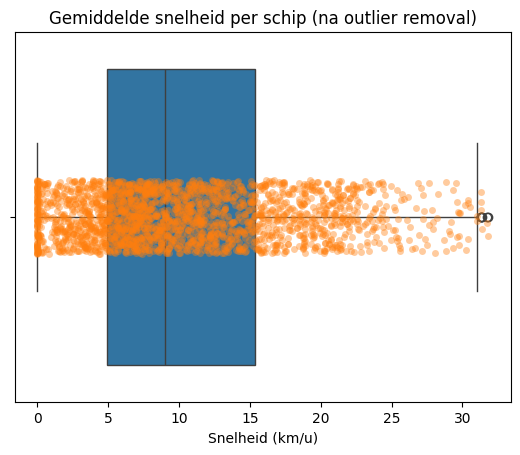

In [232]:
sns.boxplot(data = filtered_speeds, x = "SOG_kph")
sns.stripplot(data = filtered_speeds, x = "SOG_kph", alpha=0.4, jitter=True)
plt.title("Gemiddelde snelheid per schip (na outlier removal)")
plt.xlabel("Snelheid (km/u)")
plt.show()

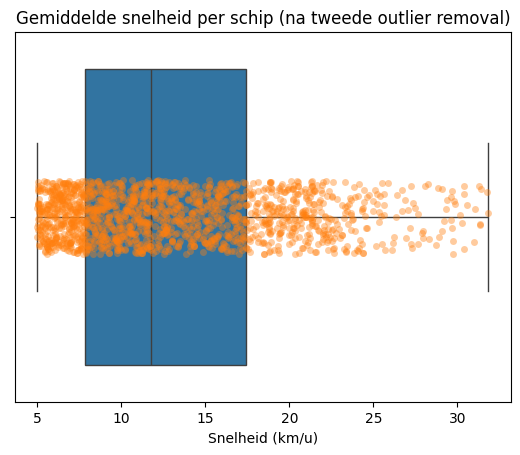

In [233]:
filtered_speeds = filtered_speeds[filtered_speeds["SOG_kph"] > 5]

sns.boxplot(data = filtered_speeds, x = "SOG_kph")
sns.stripplot(data = filtered_speeds, x = "SOG_kph", alpha=0.4, jitter=True)
plt.title("Gemiddelde snelheid per schip (na tweede outlier removal)")
plt.xlabel("Snelheid (km/u)")
plt.show()

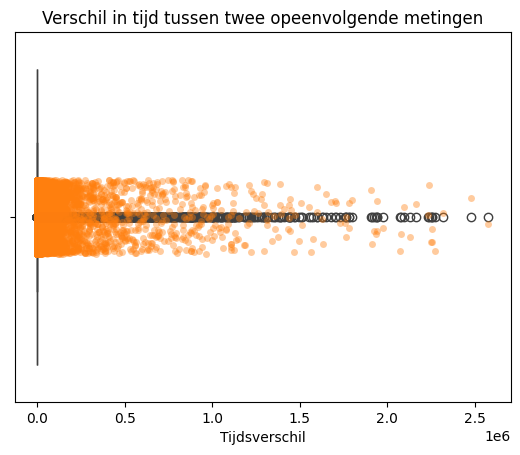

In [250]:
# tijd tussen twee opeenvolgende punten
filtered_cargo_data = cargo_AIS_data[cargo_AIS_data["MMSI"].isin(filtered_speeds["MMSI"].unique())]
time_df = filtered_cargo_data.sort_values(["MMSI", "BaseDateTime"]).reset_index()
time_df["TimeDiff"] = time_df.groupby("MMSI")["BaseDateTime"].diff().dt.total_seconds()
time_df.sort_values(["MMSI", "BaseDateTime"])

sns.boxplot(data = time_df, x = "TimeDiff", )
sns.stripplot(data = time_df, x = "TimeDiff", alpha=0.4, jitter=True)
plt.title("Verschil in tijd tussen twee opeenvolgende metingen")
plt.xlabel("Tijdsverschil")
plt.show()

In [253]:
gap_threshold = time_df["TimeDiff"].quantile(0.99)

In [261]:
df_test = time_df[time_df["MMSI"] == 563935000].copy()
df_test["is_new_route"] = df_test["TimeDiff"] > gap_threshold
df_test["route_id"] = df_test["is_new_route"].cumsum()

route_counts = df_test.groupby("route_id").size().reset_index(name="aantal_rijen")
correct_routes = route_counts[route_counts["aantal_rijen"] >= 10]["route_id"]
df_test_filtered = df_test[df_test["route_id"].isin(correct_routes)]

- maak hier nu een plaatje van de enkele route dus van mmsi 563935000
- en dan vervolgens met alle verschillende routes
- kies dan vervolgens welke je wel wilt meenemen en welke niet 

In [198]:
import folium
import random
import matplotlib.colors as mcolors
from folium.features import CustomIcon

def extract_plot_data_by_MMSI(AIS_data, MMSI_list, RF_data=None, include_AIS=True, include_RF=False):
    """
    Extracts AIS and/or RF data for a given list of MMSIs.
    
    Args:
        AIS_data (pd.DataFrame): AIS data
        RF_data (pd.DataFrame): RF data, defaults to None
        MMSI_list (list): List of MMSI numbers to filter by
        include_AIS (bool): Whether to include AIS data, defaults to True
        include_RF (bool): Whether to include RF data, defaults to False

    Returns:
        tuple: Filtered AIS and RF data
    """
    filtered_AIS = None
    filtered_RF = None

    if include_AIS and AIS_data is not None:
        filtered_AIS = AIS_data[AIS_data["MMSI"].isin(MMSI_list)]

    if include_RF and RF_data is not None:
        filtered_RF = RF_data[RF_data["MMSI"].isin(MMSI_list)]

    return filtered_AIS, filtered_RF

def map_vessel_route(AIS_data, MMSI_list, RF_data=None, include_AIS=True, include_RF=False): 
    """
    Plots the routes of vessels on an interactive map using Folium.

    Args:
        AIS_data (pd.DataFrame): AIS data
        RF_data (pd.DataFrame): RF data, defaults to None
        MMSI_list (list): List of MMSI numbers to filter by
        include_AIS (bool): Whether to include AIS data points in the plot, defaults to True
        include_RF (bool): Whether to include RF data points in the plot, defaults to False

    Returns:
        folium.Map: Interactive folium map
    """
    # Get the filtered data
    AIS_data, RF_data = extract_plot_data_by_MMSI(AIS_data, MMSI_list, RF_data, include_AIS, include_RF)
    
    # Determine center of the map
    if AIS_data is not None and not AIS_data.empty:
        map_center = [AIS_data["LAT"].mean(), AIS_data["LON"].mean()]
    elif RF_data is not None and not RF_data.empty:
        map_center = [RF_data["RF_LAT"].mean(), RF_data["RF_LON"].mean()]
    else:
        return folium.Map(location=[0, 0], zoom_start=2)

    # Create map
    map = folium.Map(location=map_center, zoom_start=7, tiles="CartoDB Positron")
    colors = list(mcolors.CSS4_COLORS.keys()) 

    # Plot AIS data
    if AIS_data is not None and not AIS_data.empty:
        for i, (mmsi, group) in enumerate(AIS_data.groupby('MMSI')):
            AIS_filter = folium.FeatureGroup(name=f"AIS data points {mmsi}")
            color = random.choice(colors)
            
            for _, row in group.iterrows():
                heading = 315 + row.get('Heading', 0)
                icon_html = f'''
                    <div style="font-size:12px; transform: rotate({heading}deg);">
                        <i class="fa-solid fa-location-arrow" style="color: {color};"></i>
                    </div>
                    '''
                folium.Marker(
                    location=(row['LAT'], row['LON']),
                    tooltip=f"AIS data point<br>MMSI: {mmsi}<br>Timestamp: {row['BaseDateTime']}",
                    icon=folium.DivIcon(html=icon_html)
                ).add_to(AIS_filter)
                
            AIS_filter.add_to(map)

    # Plot RF data
    if RF_data is not None and not RF_data.empty:
        RF_filter = folium.FeatureGroup(name="RF data points")
        
        for (mmsi, timestamp), group in RF_data.groupby(['MMSI', 'TimeStamp_RF']):
            for _, row in group.iterrows():
                custom_icon = CustomIcon(
                    icon_image="../images/star_image_yellow.png",
                    icon_size=(30, 30),
                    icon_anchor=(15, 15)
                )
                folium.Marker(
                    location=[row['RF_LAT'], row['RF_LON']],
                    icon=custom_icon,
                    tooltip=f"RF data point<br>MMSI: {mmsi}<br>Timestamp: {row['TimeStamp_RF']}",
                ).add_to(RF_filter)
                
        RF_filter.add_to(map)

    # Add layer control
    folium.LayerControl(collapsed=False).add_to(map)

    return map


In [201]:
import folium
import random
import matplotlib.colors as mcolors
from folium.features import CustomIcon

def map_vessel_route_2(AIS_data, MMSI_list, RF_data=None, include_AIS=True, include_RF=False): 
    """
    Plots the routes of vessels on an interactive map using Folium.

    Args:
        AIS_data (pd.DataFrame): AIS data
        RF_data (pd.DataFrame): RF data, defaults to None
        MMSI_list (list): List of MMSI numbers to filter by
        include_AIS (bool): Whether to include AIS data points in the plot, defaults to True
        include_RF (bool): Whether to include RF data points in the plot, defaults to False

    Returns:
        folium.Map: Interactive folium map
    """
    # Get filtered data
    AIS_data, RF_data = extract_plot_data_by_MMSI(AIS_data, MMSI_list, RF_data, include_AIS, include_RF)
    
    # Determine map center
    if AIS_data is not None and not AIS_data.empty:
        map_center = [AIS_data["LAT"].mean(), AIS_data["LON"].mean()]
    elif RF_data is not None and not RF_data.empty:
        map_center = [RF_data["RF_LAT"].mean(), RF_data["RF_LON"].mean()]
    else:
        return folium.Map(location=[0, 0], zoom_start=2)

    # Create map
    map = folium.Map(location=map_center, zoom_start=7, tiles="CartoDB Positron")
    colors = list(mcolors.CSS4_COLORS.keys())

    # Plot AIS data with color per SubTrackID
    if AIS_data is not None and not AIS_data.empty:
        for (mmsi, subtrack), group in AIS_data.groupby(['MMSI', 'route_id']):
            AIS_filter = folium.FeatureGroup(name=f"AIS MMSI: {mmsi}, Route ID: {subtrack}")
            color = random.choice(colors)
            
            for _, row in group.iterrows():
                heading = 315 + row.get('Heading', 0)
                icon_html = f'''
                    <div style="font-size:12px; transform: rotate({heading}deg);">
                        <i class="fa-solid fa-location-arrow" style="color: {color};"></i>
                    </div>
                    '''
                folium.Marker(
                    location=(row['LAT'], row['LON']),
                    tooltip=f"AIS data point<br>MMSI: {mmsi}<br>Route ID: {subtrack}<br>Timestamp: {row['BaseDateTime']}",
                    icon=folium.DivIcon(html=icon_html)
                ).add_to(AIS_filter)
            
            AIS_filter.add_to(map)

    # Plot RF data (optioneel)
    if RF_data is not None and not RF_data.empty:
        RF_filter = folium.FeatureGroup(name="RF data points")
        
        for (mmsi, timestamp), group in RF_data.groupby(['MMSI', 'TimeStamp_RF']):
            for _, row in group.iterrows():
                custom_icon = CustomIcon(
                    icon_image="../images/star_image_yellow.png",
                    icon_size=(30, 30),
                    icon_anchor=(15, 15)
                )
                folium.Marker(
                    location=[row['RF_LAT'], row['RF_LON']],
                    icon=custom_icon,
                    tooltip=f"RF data point<br>MMSI: {mmsi}<br>Timestamp: {row['TimeStamp_RF']}",
                ).add_to(RF_filter)
        
        RF_filter.add_to(map)

    # Layer control
    folium.LayerControl(collapsed=False).add_to(map)

    return map


In [259]:
map_vessel_route(time_df, [563935000])

In [282]:
map_vessel_route_2(df_test_filtered, [563935000])